In [1]:
pwd

'D:\\樓上志偉\\2025實測\\notebooks'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns

pd.options.mode.copy_on_write = True
fm.fontManager.addfont('..\\TaipeiSansTCBeta-Regular.ttf')
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = 'Taipei Sans TC Beta'

In [3]:
# directory_file = '..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_HALF_LOAD_1ST.csv'
directory_file = '..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_FULL_LOAD_1ST.csv'
df = pd.read_csv(directory_file, header=2, usecols=['GPS_Altitude', 'GPS_VehicleSpeed', 'OBD_EngineSpeed', 'OBD_EngineFuelRate'])
df.columns=['GPS_Altitude[m]', 'VehicleSpeed[km/h]', 'EngineSpeed[rpm]', 'EngineFuelRate[L/h]']

df['acceleration[m/s^2]'] = 0.
for i in range(1,len(df)):
    df.loc[i, 'acceleration[m/s^2]'] = (df.loc[i,'VehicleSpeed[km/h]'] - df.loc[i-1,'VehicleSpeed[km/h]']) / 3.6 # 逐秒資料

df['delta_EngineSpeed[rpm]'] = 0.
for i in range(1,len(df)):
    df.loc[i, 'delta_EngineSpeed[rpm]'] = df.loc[i,'EngineSpeed[rpm]'] - df.loc[i-1,'EngineSpeed[rpm]']

df['delta_Altitude[m]'] = 0.
for i in range(1,len(df)):
    df.loc[i, 'delta_Altitude[m]'] = df.loc[i,'GPS_Altitude[m]'] - df.loc[i-1,'GPS_Altitude[m]']

In [4]:
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

X = df[['GPS_Altitude[m]', 'delta_Altitude[m]', 'VehicleSpeed[km/h]', 'acceleration[m/s^2]', 'EngineSpeed[rpm]', 'delta_EngineSpeed[rpm]']]
y = df['EngineFuelRate[L/h]']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
regr = MLPRegressor(random_state=1,
                    hidden_layer_sizes=(6, 2),
                    max_iter=200000,
                    tol=0.000001,
                    learning_rate_init=0.01,
                    early_stopping=True
                   )
regr.fit(X_scaled, y)
y_predict = regr.predict(X_scaled)
r2 = r2_score(y, y_predict)
print(f"R2={r2:.4f}")

R2=0.6900


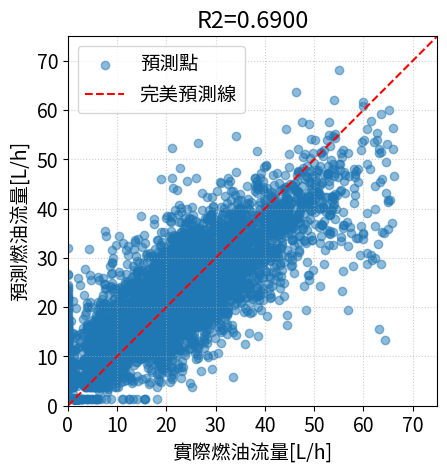

In [5]:
fig = plt.figure() 
plt.scatter(y, y_predict, alpha=0.5, label='預測點')
line_coords = np.linspace(0, 75, 100) 
plt.plot(line_coords, line_coords,
         color='red',
         linestyle='--',
         label='完美預測線')
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"R2={r2:.4f}")
plt.xlabel('實際燃油流量[L/h]')
plt.ylabel('預測燃油流量[L/h]')
ticks = np.arange(0, 80, 10)
plt.xticks(ticks)
plt.yticks(ticks)
plt.xlim(xmin=0, xmax=75)
plt.ylim(0, 75)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [6]:
df

,GPS_Altitude[m],VehicleSpeed[km/h],EngineSpeed[rpm],EngineFuelRate[L/h],acceleration[m/s^2],delta_EngineSpeed[rpm],delta_Altitude[m]
0,8.3,0.157,502.50,1.60,0.000000,0.00,0.000000
1,8.2,0.130,502.00,1.60,-0.007500,-0.50,-0.100000
2,8.1,0.088,500.25,1.65,-0.011667,-1.75,-0.099999
3,7.9,0.159,498.50,1.70,0.019722,-1.75,-0.200000
4,7.9,0.095,497.25,1.80,-0.017778,-1.25,0.000000
...,...,...,...,...,...,...,...
5487,5.6,0.156,501.25,1.85,0.019167,0.25,0.100000
5488,5.6,0.096,499.25,1.85,-0.016667,-2.00,0.000000
5489,5.7,0.158,498.75,1.90,0.017222,-0.50,0.100000
5490,5.8,0.113,495.00,2.00,-0.012500,-3.75,0.100000


In [7]:
import pickle

# with open("..//models//model_8_hidden_6_2_HALF_LOAD.pkl", 'wb') as f:
with open("..//models//model_8_hidden_6_2_FULL_LOAD.pkl", 'wb') as f:
    pickle.dump(regr, f)

# with open('..//models//model_8_scaler_HALF_LOAD.pkl', 'wb') as f:
with open('..//models//model_8_scaler_FULL_LOAD.pkl', 'wb') as f:
    pickle.dump(scaler, f)